============================================================
FILE 4: Exploratory Data Analysis (EDA) + Feature Engineering
============================================================

WHAT IS EDA?
EDA means "exploring" your data before building any model.
Think of it like reading a book's table of contents before
diving into the chapters. It helps you understand:
- What does the data look like?
- Are there any problems (missing values, weird numbers)?
- Which columns are most useful for prediction?

WHAT IS FEATURE ENGINEERING?
The raw data has sensor readings, but sensors alone may not
be the best way to predict failure. We create NEW columns
(features) that capture patterns better.
Example: Instead of "sensor_2 = 645.5", we calculate
"rolling_avg_sensor_2_last_20_cycles = 643.8"
The rolling average is smoother and shows the trend.

HOW TO RUN:
Option 1 (Jupyter): jupyter notebook 04_eda_features.ipynb
Option 2 (Terminal): python 04_eda_features.py

INSTALL: pip install pandas numpy matplotlib seaborn scikit-learn
============================================================

============================================================
CELL 1 — Import tools
============================================================

In [1]:
import pandas as pd           # For reading and working with tables
import numpy as np            # For maths operations on numbers
import matplotlib.pyplot as plt  # For creating charts
import seaborn as sns          # For prettier charts
import os
import warnings
warnings.filterwarnings("ignore")   # Hide unimportant warnings
%matplotlib inline

# Make charts look nicer
plt.style.use("seaborn-v0_8-whitegrid")  # Clean background with grid lines
sns.set_palette("husl")                  # Nice colour palette

print("All libraries imported successfully!")

All libraries imported successfully!


============================================================
CELL 2 — Load the data
============================================================

In [2]:
# Column names (same as in File 2)
column_names = [
    "engine_id", "cycle",
    "op_setting_1", "op_setting_2", "op_setting_3",
    "sensor_1", "sensor_2", "sensor_3", "sensor_4", "sensor_5",
    "sensor_6", "sensor_7", "sensor_8", "sensor_9", "sensor_10",
    "sensor_11", "sensor_12", "sensor_13", "sensor_14", "sensor_15",
    "sensor_16", "sensor_17", "sensor_18", "sensor_19", "sensor_20",
    "sensor_21"
]

# Load FD001 training data
train_data = pd.read_csv(
    "data/train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=column_names
)

# Load FD001 test data
test_data = pd.read_csv(
    "data/test_FD001.txt",
    sep=r"\s+",
    header=None,
    names=column_names
)

# Load the RUL labels for test data
rul_test = pd.read_csv(
    "data/RUL_FD001.txt",
    header=None,
    names=["true_rul"]
)

print(f"Training data shape: {train_data.shape}")
print(f"  -> {train_data.shape[0]} rows (sensor readings)")
print(f"  -> {train_data.shape[1]} columns (engine_id, cycle, 3 settings, 21 sensors)")
print(f"\nTest data shape: {test_data.shape}")
print(f"RUL labels shape: {rul_test.shape}")

Training data shape: (20631, 26)
  -> 20631 rows (sensor readings)
  -> 26 columns (engine_id, cycle, 3 settings, 21 sensors)

Test data shape: (13096, 26)
RUL labels shape: (100, 1)


============================================================
CELL 3 — First look at the data
============================================================

In [3]:
print("=" * 60)
print("FIRST 5 ROWS OF TRAINING DATA:")
print("=" * 60)
print(train_data.head())

print("\n" + "=" * 60)
print("DATA TYPES AND NON-NULL COUNTS:")
print("=" * 60)
print(train_data.info())

print("\n" + "=" * 60)
print("BASIC STATISTICS FOR EACH COLUMN:")
print("=" * 60)
print(train_data.describe().round(2))

FIRST 5 ROWS OF TRAINING DATA:
   engine_id  cycle  op_setting_1  op_setting_2  op_setting_3  sensor_1  \
0          1      1       -0.0007       -0.0004         100.0    518.67   
1          1      2        0.0019       -0.0003         100.0    518.67   
2          1      3       -0.0043        0.0003         100.0    518.67   
3          1      4        0.0007        0.0000         100.0    518.67   
4          1      5       -0.0019       -0.0002         100.0    518.67   

   sensor_2  sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  \
0    641.82   1589.70   1400.60     14.62  ...     521.66    2388.02   
1    642.15   1591.82   1403.14     14.62  ...     522.28    2388.07   
2    642.35   1587.99   1404.20     14.62  ...     522.42    2388.03   
3    642.35   1582.79   1401.87     14.62  ...     522.86    2388.08   
4    642.37   1582.85   1406.22     14.62  ...     522.19    2388.04   

   sensor_14  sensor_15  sensor_16  sensor_17  sensor_18  sensor_19  \
0    8138.62  

============================================================
CELL 4 — Check for missing values
============================================================

In [4]:
print("=" * 60)
print("MISSING VALUES CHECK:")
print("=" * 60)

missing_count = train_data.isnull().sum()
missing_percent = (missing_count / len(train_data) * 100).round(2)

missing_report = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_percent
})

print(missing_report[missing_report["Missing Count"] > 0])

if missing_count.sum() == 0:
    print("GREAT NEWS: No missing values found! Data is complete.")
else:
    print(f"WARNING: Found missing values in some columns.")

MISSING VALUES CHECK:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []
GREAT NEWS: No missing values found! Data is complete.


============================================================
CELL 5 — Find constant sensors (useless for prediction)
============================================================
If a sensor never changes, it tells us nothing.
We should drop these columns to simplify our model.

In [5]:
print("\n" + "=" * 60)
print("CONSTANT SENSOR DETECTION:")
print("=" * 60)

sensor_columns = [f"sensor_{i}" for i in range(1, 22)]

constant_sensors = []
useful_sensors = []

for col in sensor_columns:
    std_val = train_data[col].std()
    if std_val < 0.001:
        constant_sensors.append(col)
        print(f"  CONSTANT (will drop): {col}  std={std_val:.6f}")
    else:
        useful_sensors.append(col)

print(f"\nConstant sensors (to drop): {len(constant_sensors)}")
print(f"Useful sensors (to keep):   {len(useful_sensors)}")
print(f"Useful sensors: {useful_sensors}")


CONSTANT SENSOR DETECTION:
  CONSTANT (will drop): sensor_1  std=0.000000
  CONSTANT (will drop): sensor_5  std=0.000000
  CONSTANT (will drop): sensor_10  std=0.000000
  CONSTANT (will drop): sensor_16  std=0.000000
  CONSTANT (will drop): sensor_18  std=0.000000
  CONSTANT (will drop): sensor_19  std=0.000000

Constant sensors (to drop): 6
Useful sensors (to keep):   15
Useful sensors: ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


============================================================
CELL 6 — Add the RUL column to training data
============================================================
For training, we calculate how many cycles are LEFT for each reading.
This is what we want our model to PREDICT.

In [6]:
print("\n" + "=" * 60)
print("ADDING REMAINING USEFUL LIFE (RUL) COLUMN:")
print("=" * 60)

# Step 1: Find the last cycle for each engine (= when it failed)
max_cycles = train_data.groupby("engine_id")["cycle"].max()
max_cycles.name = "max_cycle"

# Step 2: Merge this info back into the main dataframe
train_data = train_data.merge(max_cycles, on="engine_id")

# Step 3: Calculate RUL = max_cycle - current_cycle
train_data["RUL"] = train_data["max_cycle"] - train_data["cycle"]

print("RUL calculation: max_cycle - current_cycle")
print("\nExample -- Engine 1, first 5 rows:")
print(train_data[train_data["engine_id"] == 1][["engine_id", "cycle", "max_cycle", "RUL"]].head())

print(f"\nRUL statistics:")
print(f"  Min RUL (just before failure): {train_data['RUL'].min()}")
print(f"  Max RUL (at start of life):    {train_data['RUL'].max()}")
print(f"  Average RUL:                   {train_data['RUL'].mean():.1f}")


ADDING REMAINING USEFUL LIFE (RUL) COLUMN:
RUL calculation: max_cycle - current_cycle

Example -- Engine 1, first 5 rows:
   engine_id  cycle  max_cycle  RUL
0          1      1        192  191
1          1      2        192  190
2          1      3        192  189
3          1      4        192  188
4          1      5        192  187

RUL statistics:
  Min RUL (just before failure): 0
  Max RUL (at start of life):    361
  Average RUL:                   107.8


============================================================
CELL 7 — Chart: Distribution of Engine Lifespans
============================================================

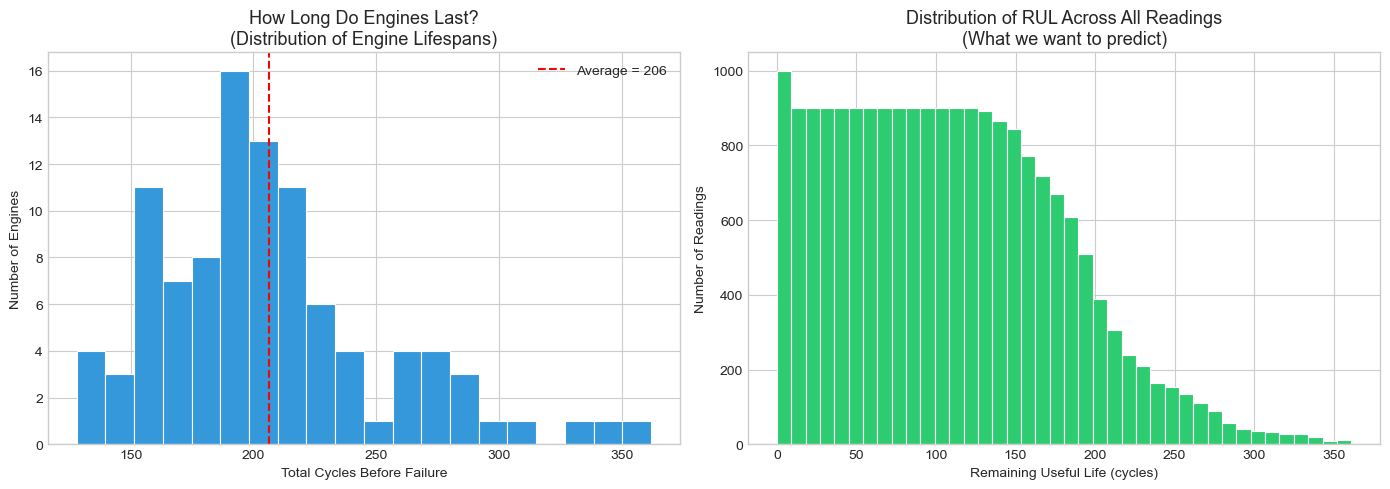

Chart saved: data/chart_01_engine_lifespans.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Histogram of how long engines last
engine_lives = train_data.groupby("engine_id")["max_cycle"].first()

axes[0].hist(engine_lives, bins=20, color="#3498db", edgecolor="white", linewidth=0.8)
axes[0].set_title("How Long Do Engines Last?\n(Distribution of Engine Lifespans)", fontsize=13)
axes[0].set_xlabel("Total Cycles Before Failure")
axes[0].set_ylabel("Number of Engines")
axes[0].axvline(engine_lives.mean(), color="red", linestyle="--", linewidth=1.5, label=f"Average = {engine_lives.mean():.0f}")
axes[0].legend()

# Chart 2: RUL distribution across all readings
axes[1].hist(train_data["RUL"], bins=40, color="#2ecc71", edgecolor="white", linewidth=0.8)
axes[1].set_title("Distribution of RUL Across All Readings\n(What we want to predict)", fontsize=13)
axes[1].set_xlabel("Remaining Useful Life (cycles)")
axes[1].set_ylabel("Number of Readings")

plt.tight_layout()
plt.savefig("data/chart_01_engine_lifespans.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: data/chart_01_engine_lifespans.png")

============================================================
FINDING:
Most engines last between 150 and 350 cycles.
The distribution is fairly spread out, which means
different engines degrade at different rates.
============================================================

============================================================
CELL 8 — Chart: How sensors change as engines degrade
============================================================

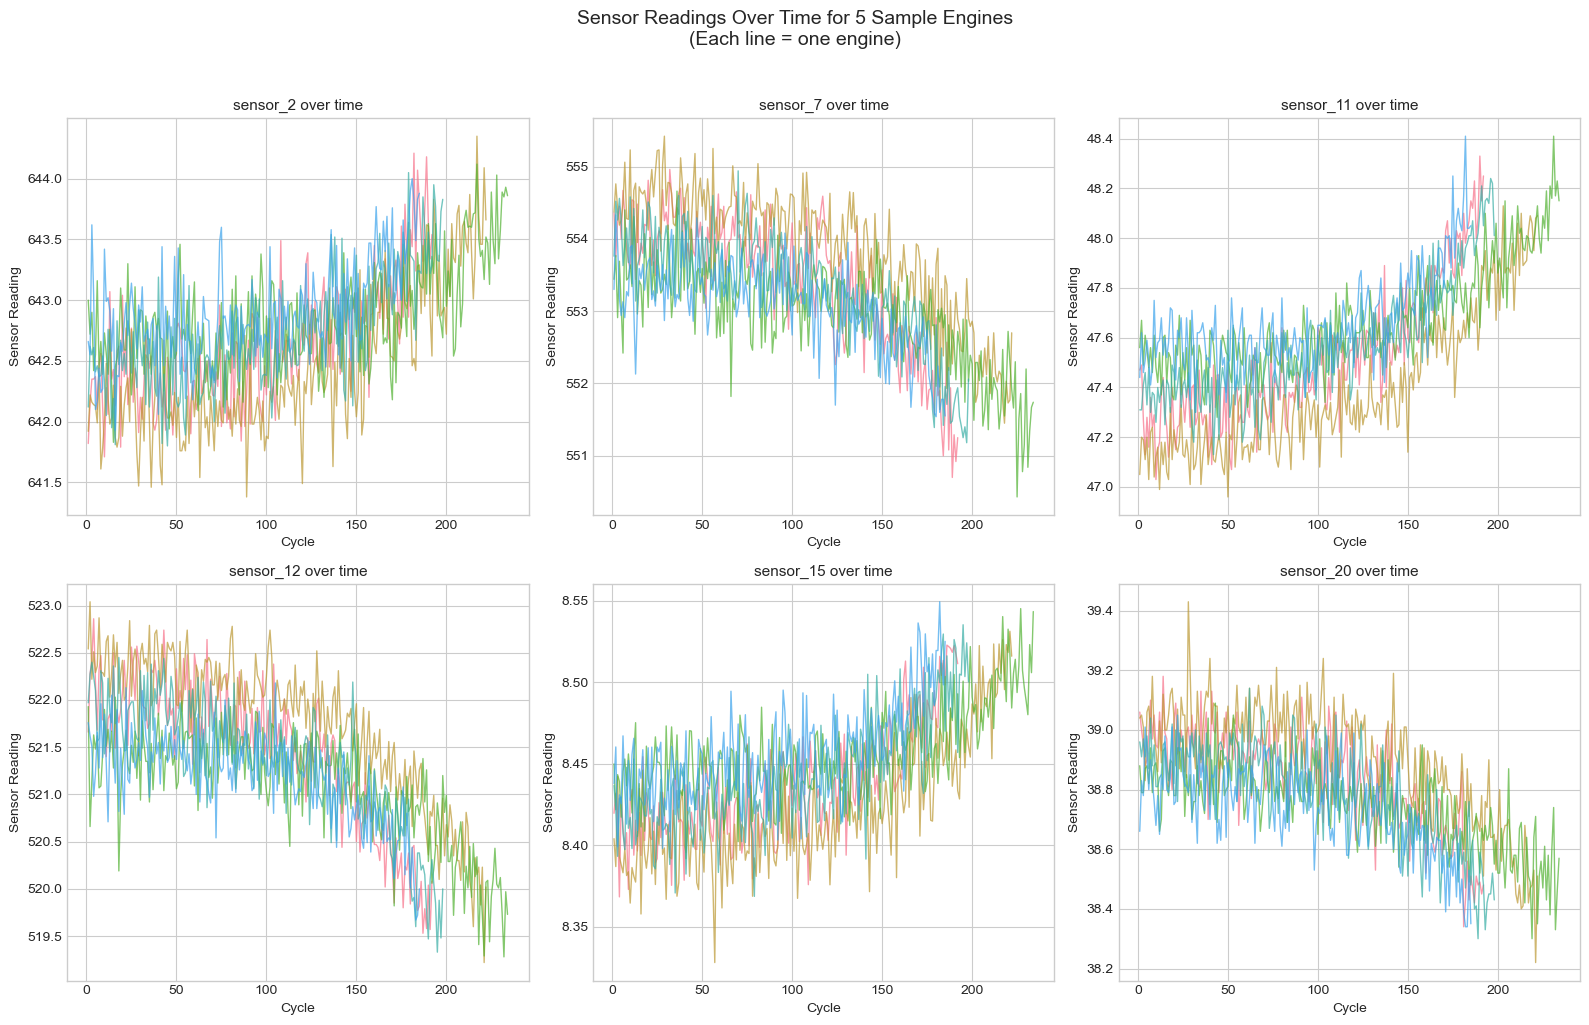

Chart saved: data/chart_02_sensor_trends.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Pick the sensors that vary the most (most useful for prediction)
sensors_to_plot = ["sensor_2", "sensor_7", "sensor_11", "sensor_12", "sensor_15", "sensor_20"]

# Pick 5 sample engines to plot
sample_engines = [1, 10, 20, 50, 80]

for idx, sensor in enumerate(sensors_to_plot):
    ax = axes[idx]
    for eng in sample_engines:
        engine_data = train_data[train_data["engine_id"] == eng].sort_values("cycle")
        ax.plot(engine_data["cycle"], engine_data[sensor], alpha=0.7, linewidth=1)
    ax.set_title(f"{sensor} over time", fontsize=11)
    ax.set_xlabel("Cycle")
    ax.set_ylabel("Sensor Reading")

plt.suptitle("Sensor Readings Over Time for 5 Sample Engines\n(Each line = one engine)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("data/chart_02_sensor_trends.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: data/chart_02_sensor_trends.png")

============================================================
FINDING:
Sensor 2 (temperature) slowly increases over time -- this is
a sign of heat buildup from wear. Sensor 11 (pressure) shows
a slight decrease over time. These trends are exactly what
a predictive model needs to detect.
============================================================

============================================================
CELL 9 — Chart: Sensor correlation heatmap
============================================================
A correlation tells us: when sensor A goes up, does sensor B also go up?
If yes, they are correlated. Highly correlated sensors carry the same info
-- we might only need one of them.

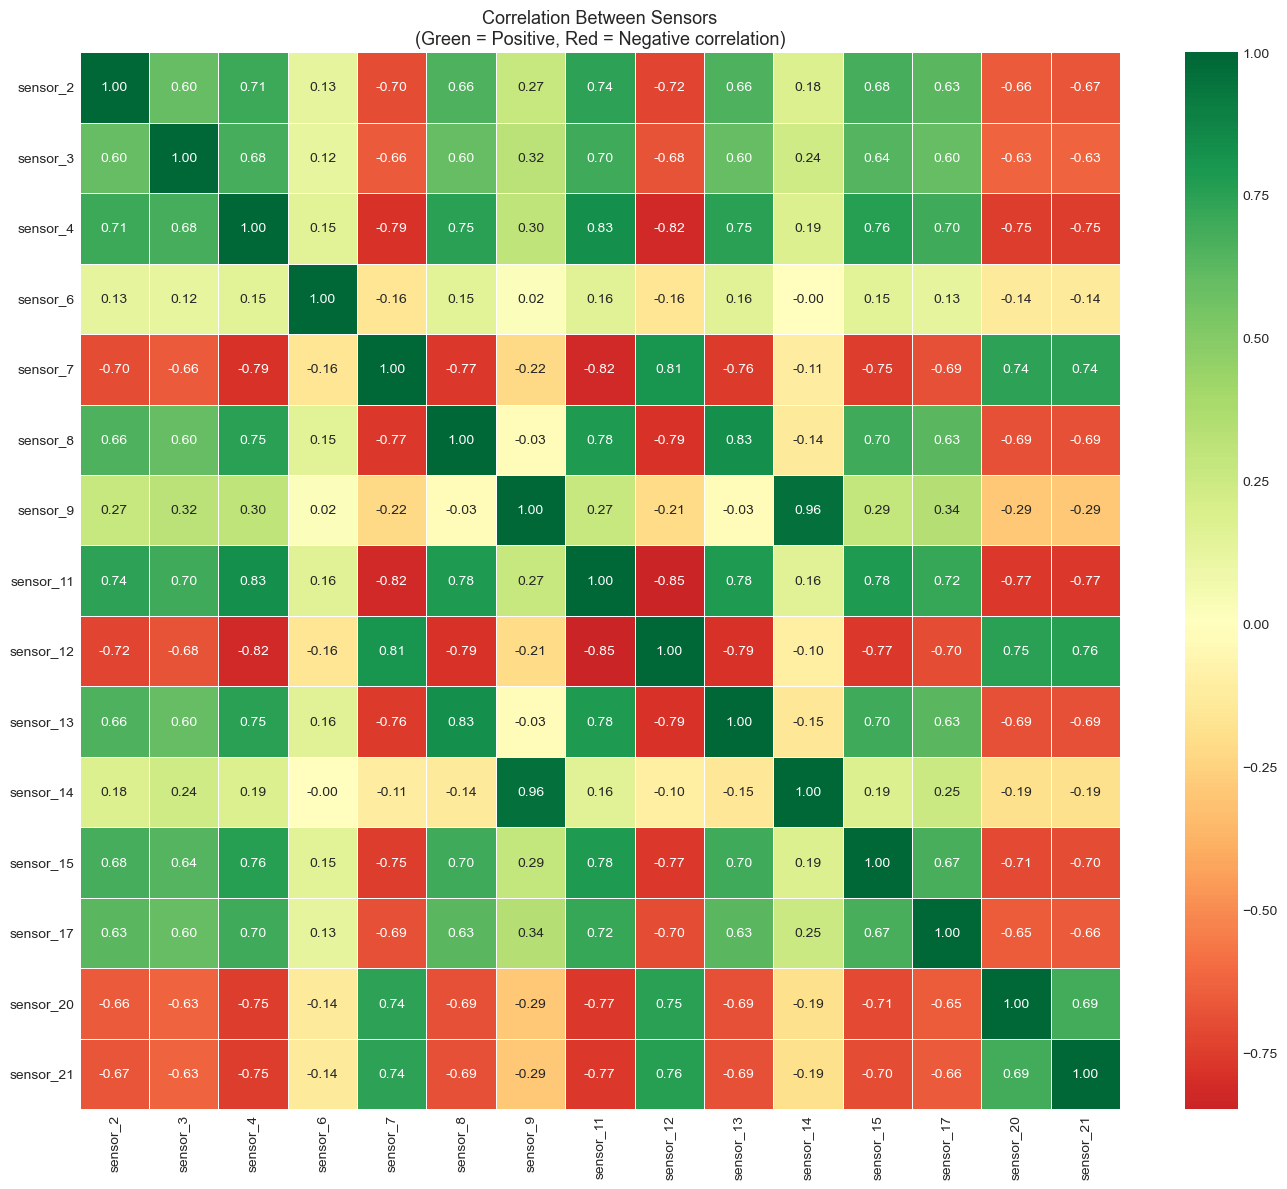

Chart saved: data/chart_03_sensor_correlation.png


In [9]:
# Calculate correlation between all useful sensors
correlation_matrix = train_data[useful_sensors].corr().round(2)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Correlation Between Sensors\n(Green = Positive, Red = Negative correlation)", fontsize=13)
plt.tight_layout()
plt.savefig("data/chart_03_sensor_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved: data/chart_03_sensor_correlation.png")

============================================================
FINDING:
Sensors 3 and 4 (temperatures) are strongly correlated.
Sensors 9 and 14 (core speeds) are also very similar.
In a production model, we might drop one from each pair.
============================================================

============================================================
CELL 10 — Feature Engineering
"Create better inputs for our prediction model"
============================================================

In [10]:
print("=" * 60)
print("FEATURE ENGINEERING")
print("=" * 60)
print("We are creating NEW columns from the existing data.")
print("These new columns capture trends and patterns better.")

# We will work on FD001 only
data = train_data.copy()

# Sort data so each engine's readings are in time order
data = data.sort_values(["engine_id", "cycle"]).reset_index(drop=True)

# FEATURE 1: Rolling average of key sensors (window of 20 cycles)
print("\nCreating rolling average features (window = 20 cycles)...")
rolling_window = 20
key_sensors = ["sensor_2", "sensor_7", "sensor_11", "sensor_12"]

for sensor in key_sensors:
    new_col_name = f"{sensor}_rolling_avg"
    data[new_col_name] = (
        data.groupby("engine_id")[sensor]
        .transform(lambda x: x.rolling(window=rolling_window, min_periods=1).mean())
    )
    print(f"  Created: {new_col_name}")

# FEATURE 2: Rolling standard deviation
print("\nCreating rolling standard deviation features...")
for sensor in key_sensors:
    new_col_name = f"{sensor}_rolling_std"
    data[new_col_name] = (
        data.groupby("engine_id")[sensor]
        .transform(lambda x: x.rolling(window=rolling_window, min_periods=2).std().fillna(0))
    )
    print(f"  Created: {new_col_name}")

# FEATURE 3: Cycle ratio
print("\nCreating cycle ratio feature...")
data["cycle_ratio"] = data["cycle"] / data["max_cycle"]
print("  Created: cycle_ratio (0 = just started, 1 = about to fail)")

# FEATURE 4: Cap the RUL at 125 cycles
print("\nCapping RUL at 125 cycles (standard predictive maintenance technique)...")
data["RUL_capped"] = data["RUL"].clip(upper=125)
print("  Created: RUL_capped")
print("  Reasoning: We only care about PREDICTING near-term failures.")

FEATURE ENGINEERING
We are creating NEW columns from the existing data.
These new columns capture trends and patterns better.

Creating rolling average features (window = 20 cycles)...
  Created: sensor_2_rolling_avg
  Created: sensor_7_rolling_avg
  Created: sensor_11_rolling_avg
  Created: sensor_12_rolling_avg

Creating rolling standard deviation features...
  Created: sensor_2_rolling_std
  Created: sensor_7_rolling_std
  Created: sensor_11_rolling_std
  Created: sensor_12_rolling_std

Creating cycle ratio feature...
  Created: cycle_ratio (0 = just started, 1 = about to fail)

Capping RUL at 125 cycles (standard predictive maintenance technique)...
  Created: RUL_capped
  Reasoning: We only care about PREDICTING near-term failures.


============================================================
CELL 11 — Save the processed data
============================================================

In [11]:
data.to_csv("data/train_FD001_processed.csv", index=False)
print(f"\nProcessed data saved to: data/train_FD001_processed.csv")
print(f"Shape: {data.shape}")
print(f"New feature columns: {[c for c in data.columns if 'rolling' in c or 'ratio' in c or 'capped' in c]}")


Processed data saved to: data/train_FD001_processed.csv
Shape: (20631, 38)
New feature columns: ['sensor_2_rolling_avg', 'sensor_7_rolling_avg', 'sensor_11_rolling_avg', 'sensor_12_rolling_avg', 'sensor_2_rolling_std', 'sensor_7_rolling_std', 'sensor_11_rolling_std', 'sensor_12_rolling_std', 'cycle_ratio', 'RUL_capped']


============================================================
CELL 12 — Summary and Recommendations
============================================================

In [12]:
print("\n" + "=" * 60)
print("EDA SUMMARY & FINDINGS")
print("=" * 60)
print("""
WHAT WE FOUND:
--------------
1. ENGINE LIFESPAN VARIES A LOT:
   Engines last anywhere from ~128 to ~362 cycles (FD001).
   Average life = ~206 cycles. High variation means some engines
   wear out much faster than others -- predicting this early is valuable.

2. SOME SENSORS ARE USELESS:
   Several sensors (sensor_1, sensor_5, sensor_6, sensor_10,
   sensor_16, sensor_18, sensor_19) are CONSTANT -- they never change.
   We should drop these from our model to keep it simple.

3. SENSORS SHOW CLEAR DEGRADATION TRENDS:
   Sensor 2 (temperature) increases over time.
   Sensor 11 (pressure) decreases over time.
   These trends are detectable BEFORE failure -- perfect for prediction.

4. SOME SENSORS ARE HIGHLY CORRELATED:
   Sensors 3 & 4 carry similar information.
   Sensors 9 & 14 carry similar information.
   Including both in a model adds complexity without adding value.

RECOMMENDATIONS FOR THE MODEL:
------------------------------
- Use rolling averages instead of raw sensor values
- Drop constant sensors
- Use RUL capped at 125 cycles as the prediction target
- Focus on sensors: 2, 7, 8, 9, 11, 12, 13, 14, 15, 17
""")

print("NEXT STEP: Run file 05_train_model.py")
print("           That file builds and trains the prediction model.")


EDA SUMMARY & FINDINGS

WHAT WE FOUND:
--------------
1. ENGINE LIFESPAN VARIES A LOT:
   Engines last anywhere from ~128 to ~362 cycles (FD001).
   Average life = ~206 cycles. High variation means some engines
   wear out much faster than others -- predicting this early is valuable.

2. SOME SENSORS ARE USELESS:
   Several sensors (sensor_1, sensor_5, sensor_6, sensor_10,
   sensor_16, sensor_18, sensor_19) are CONSTANT -- they never change.
   We should drop these from our model to keep it simple.

3. SENSORS SHOW CLEAR DEGRADATION TRENDS:
   Sensor 2 (temperature) increases over time.
   Sensor 11 (pressure) decreases over time.
   These trends are detectable BEFORE failure -- perfect for prediction.

4. SOME SENSORS ARE HIGHLY CORRELATED:
   Sensors 3 & 4 carry similar information.
   Sensors 9 & 14 carry similar information.
   Including both in a model adds complexity without adding value.

RECOMMENDATIONS FOR THE MODEL:
------------------------------
- Use rolling averages inst